# Grupo 6
## **Nomes:**
### >Bandje Balde 
### >Jorje Muchanga
### >Luis Cuna

# Aplicação Estatística a problemas reais da Biologia

Nesta aula vamos analisar o crescimento de **6 microrganismos** em cultura pura, extrair parâmetros biológicos das curvas de crescimento, e aplicar testes estatísticos para comparar os organismos entre si.

**Organismos em estudo:**

| Organismo | Tipo | Patogenicidade | Ambiente natural |
|---|---|---|---|
| *E. coli* K12 | Bactéria Gram− | Comensal | Intestino humano |
| *Salmonella enterica* | Bactéria Gram− | Patogénico | Intestino, alimentos |
| *L. acidophilus* | Bactéria Gram+ | Comensal/probiótico | Intestino, vagina |
| *C. difficile* | Bactéria Gram+ | Patogénico | Intestino (oportunista) |
| *S. cerevisiae* | Levedura | Comensal/probiótico | Intestino humano, alimentos, solo |
| *C. albicans* | Levedura | Patogénico (oportunista) | Intestino, vagina |

## Curvas de Crescimento

O crescimento microbiano segue um padrão **sigmoidal** bem caracterizado, com fases distintas: **lag**, **exponencial**, **estacionária** e **declínio**. A análise quantitativa destas curvas permite extrair parâmetros biológicos que descrevem o comportamento de cada cultura.

---

### Parâmetros-chave

| Parâmetro | Símbolo | Significado biológico | Unidade |
|---|---|---|---|
| Plateau | **A** | Densidade ótica máxima atingida (capacidade de carga) | OD600 |
| Taxa de crescimento máxima | **μ_max** | Inclinação máxima da curva — quão rápido as células se dividem | OD/h |
| Fase lag | **λ** | Tempo que a cultura demora a iniciar o crescimento exponencial | horas |

---

### Porquê estes parâmetros?

Estes três parâmetros permitem responder a questões práticas importantes, como:
- **Segurança alimentar:** Quanto tempo demora um patogénico a começar a multiplicar-se num alimento? (λ)
- **Produção industrial:** Qual o organismo que atinge maior biomassa? (A)
- **Competição entre espécies:** Quem cresce mais rápido e pode dominar uma co-cultura? (μ_max)


In [1]:
# instalar Pacotes se necessário
!pip install numpy pandas matplotlib scipy statsmodels

In [5]:
# Importar Pacotes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# FASE 1 — Carregar e visualizar os dados

Antes de qualquer cálculo, é fundamental **olhar para os dados**. Vamos carregar o ficheiro CSV com as leituras de OD600 ao longo do tempo para as 6 estirpes (3 réplicas cada).

### 1.1 Abrir as medições de crescimento microbiano

O ficheiro `crescimento_microbiano.csv` contém leituras de **densidade ótica a 600 nm (OD600)** ao longo de 24 horas para as 6 estirpes, com 3 réplicas biológicas cada.

A OD600 é uma medida indireta da **concentração de células** em suspensão — quanto mais células, mais luz é dispersa e maior o valor de OD.

**Estrutura dos dados:**
- Cada **linha** = uma réplica de uma estirpe
- Cada **coluna** numérica = um ponto temporal (em horas)
- Colunas `Strain` e `Replicate` = identificação da amostra


In [8]:
# Carregar o CSV numa dataframe pandas
df = pd.read_csv('crescimento_microbiano.xls')


In [9]:
print("Boas práticas: ")

print("Verifica as primeiras linhas do DataFrame:")
print(df.head())

Boas práticas: 
Verifica as primeiras linhas do DataFrame:
                Strain Replicate      0    0.5      1    1.5      2    2.5  \
0           E_coli_K12        R1  0.142  0.110  0.150  0.196  0.290  1.106   
1           E_coli_K12        R2  0.002  0.017  0.000  0.000  0.204  0.956   
2           E_coli_K12        R3  0.000  0.000  0.000  0.000  0.073  0.964   
3  Salmonella_enterica        R1  0.000  0.000  0.026  0.000  0.014  0.148   
4  Salmonella_enterica        R2  0.000  0.000  0.033  0.004  0.000  0.184   

       3    3.5  ...      5      6      7      8      9     10     12     16  \
0  2.092  2.571  ...  2.872  2.891  2.929  2.822  2.831  2.889  2.867  2.933   
1  1.928  2.399  ...  2.884  2.810  2.760  2.855  2.753  2.824  2.716  2.747   
2  1.824  2.239  ...  2.655  2.739  2.763  2.758  2.670  2.696  2.728  2.760   
3  0.727  1.537  ...  2.531  2.407  2.596  2.562  2.543  2.563  2.459  2.548   
4  0.793  1.596  ...  2.462  2.494  2.598  2.599  2.587  2.575  2.516  2

#### **Questão**

- Quantas medições temos no total? (linhas × colunas de tempo)?
>**São no total 18 linhas e 22 colunas.**

- Os valores de OD no tempo 0 são todos iguais? O que poderia explicar pequenas diferenças?
>**-Não. Os valores de OD no tempo 0 variam ligeiramente, o que pode ser explicado por erros experimentais (pipetagem), ruído do equipamento e pequenas diferenças na concentração inicial das amostras.**
  

In [10]:
print("Verificar quais as condições a analisar")
print("Estirpe:")
print(df['Strain'].unique())

#print("Réplicas por estirpe:")
#print(df['Strain'].unique()))
print((df['Strain'] == 'C_albicans').sum())

Verificar quais as condições a analisar
Estirpe:
['E_coli_K12' 'Salmonella_enterica' 'L_acidophilus' 'C_difficile'
 'S_cerevisiae' 'C_albicans']
3


#### **Questão**
- No total quantas estirpes vamos analisar?
>**No total seram analisados 6 estirpes.**
- E quantas réplicas temos por análise?
>**Temos 3 replicas (R) por analise.**

In [13]:
print("\nEstatísticas descritivas:")
print(df.describe()) #describe


Estatísticas descritivas:
               0        0.5          1        1.5          2        2.5  \
count  18.000000  18.000000  18.000000  18.000000  18.000000  18.000000   
mean    0.062778   0.068000   0.068222   0.075778   0.094833   0.240500   
std     0.082119   0.093634   0.096481   0.096642   0.095648   0.366672   
min     0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
25%     0.000000   0.000000   0.000000   0.000000   0.000000   0.002250   
50%     0.001000   0.020500   0.022500   0.022500   0.082000   0.094500   
75%     0.113000   0.101500   0.134500   0.153000   0.165750   0.234250   
max     0.232000   0.286000   0.351000   0.319000   0.290000   1.106000   

               3        3.5          4        4.5          5          6  \
count  18.000000  18.000000  18.000000  18.000000  18.000000  18.000000   
mean    0.511278   0.715778   0.858000   0.919222   0.951389   1.096889   
std     0.727000   0.976802   1.147606   1.211050   1.265501   1.176608 

#### **Questão**
- Como varia o desvio padrão com o tempo?
>**Entre 0 a 2 horas, o desvio padrão apresenta variações pouco significativas, indicando baixa variabilidade entre as amostras. Entre 2,5 a 5 horas, observa-se um aumento acentuado do desvio padrão, correspondente à fase exponencial de crescimento, em que as diferenças entre estirpes se tornam mais evidentes. A partir das 6 até às 24 horas, o desvio padrão diminui progressivamente, refletindo a entrada na fase estacionária, onde os valores de OD tendem a estabilizar entre as culturas..**

### Atribuição de estirpes por grupo

Cada grupo altera a variável `estirpe` na célula seguinte para o seu organismo:

| Grupo | Organismo | Tipo |
|---|---|---|
| 1 | `E_coli_K12` | Bactéria comensal |
| 2 | `Salmonella_enterica` | Bactéria patogénica |
| 3 | `L_acidophilus` | Bactéria probiótica |
| 4 | `C_difficile` | Bactéria patogénica |
| 5 | `S_cerevisiae` | Levedura comensal |
| 6 | `C_albicans` | Levedura patogénica |




#### **Questão**
Antes de correr o código, o que esperam? 
- Um patogénico cresce mais rápido que um comensal?
>**Sim. Porque os patogenos possuem mecaniscmos biologicos que maximizam a velocidade de replicacao e a extracao de nutreienetes do hospedeiro, o que lhes confere taxa de cescimento mais elevada quando estao presentes no meio.**

- Uma levedura cresce mais devagar que uma bactéria?
>**Sim. Porque as leveduras tem um sistema mais complexo (eucariotica) devidem-se por gemulacao, precisando de muito mais energia para o seu crecimento, enquanto que as bacterias sao microrganismos mais simples e se dividem por fissao binaria e com pouca energia conseguem se multiplicar**

### 1.2 Filtrar os dados da vossa estirpe

Filtramos a dataframe de maneira a selecionar apenas as linhas correspondentes à estirpe escolhida, e removemos as colunas não numéricas (Strain, Replicate).

In [1]:
print('Definicao da estirpe a analisar')
estirpe = "C_albicans" # defina a estirpe a analisar

print
df_estirpe = df[df["Strain"] == estirpe] # filtrar o dataframe para a estirpe escolhida
print(df_estirpe)

# ----Filtrar a dataframe para as colunas com dados apenas
columns = df.columns.to_list() # LISTA o nome das colunas do dataframe
print(columns)

columns = df.columns.to_list() # LISTA o nome das colunas do dataframe
time_cols = columns[2:]  # mantém apenas as colunas de tempo (assumindo que as 2 primeiras são 'Strain' e 'Replicate')
print(time_cols)
                  
#print(f"DataFrame filtrado para a estirpe {estirpe}:\n{df_.head(5)}")

Definicao da estirpe a analisar


NameError: name 'df' is not defined

### 1.3 Calcular média e desvio-padrão de todos os tempos

Para cada ponto temporal, calculamos a **média** e o **desvio-padrão** das 3 réplicas.

- A **média** dá-nos o valor central da medição
- O **desvio-padrão** indica a variabilidade entre réplicas — se é pequeno, as réplicas são consistentes


In [15]:
# --- Usa a dataframe 'df_estirpe' para calcular os valores da média
print("============DATAFRAME==============")
print(df_estirpe)

print("============CALCULO DAS MEDIAS==============")
od_mean = df_estirpe[time_cols].mean().values # selecionar valores e calcular média para cada tempo
print(f"Médias calculadas por cada periodo de tempo analisado:\n{od_mean}")

print("============DESVIOS PADRAO==============")
od_std  = df_estirpe[time_cols].std().values # calcular desvio-padrão para cada tempo
print(f"Desvios-padrão:\n{od_std}")

print("============ARRAYS DE TEMPO==============")
time_array = np.array(time_cols, dtype=float) # criar array de tempos a das colunas de tempo
print(f"Array de tempos (horas): {time_array}")

============DATAFRAME==============
        Strain Replicate    0    0.5      1    1.5      2    2.5      3  \
15  C_albicans        R1  0.0  0.022  0.000  0.004  0.000  0.000  0.018   
16  C_albicans        R2  0.0  0.000  0.019  0.000  0.000  0.011  0.011   
17  C_albicans        R3  0.0  0.031  0.000  0.041  0.091  0.009  0.035   

      3.5  ...      5      6      7      8      9     10     12     16     20  \
15  0.000  ...  0.000  0.052  0.062  0.138  0.299  0.489  0.931  1.568  1.702   
16  0.000  ...  0.000  0.000  0.000  0.107  0.293  0.574  1.029  1.567  1.746   
17  0.049  ...  0.016  0.025  0.010  0.135  0.319  0.589  1.050  1.699  1.724   

       24  
15  1.825  
16  1.737  
17  1.847  

[3 rows x 22 columns]
============CALCULO DAS MEDIAS==============
Médias calculadas por cada periodo de tempo analisado:
[0.         0.01766667 0.00633333 0.015      0.03033333 0.00666667
 0.02133333 0.01633333 0.031      0.012      0.00533333 0.02566667
 0.024      0.12666667 0.30366667

#### **Questão:**

Olhando para a média dos valores, consegues antever:
- quando acaba a fase de adaptação do crescimento (lag)?
>**A fase lag estende-se aproximadamente até 8 horas.**

- quando começa  a fase de crescimento exponencial?
>**A fase de crescimento exponencial inicia-se depois do termino da anterior, as 8 horas, sendo caracterizada por um
aumento rápido e acentuado dos valores médios de OD.** 

- quando se inicia a fase estacinária?   
>**A fase estacionária inicia-se as 16 horas, momento em que os valores médios começam a estabilizar, indicando que o crescimento celular atinge um equilíbrio.**

### 1.4 Representação gráfica

Vamos representar a curva de crescimento com a média ± desvio-padrão (barras de erro), mas também todas as réplicas individualmente.


        Strain Replicate    0    0.5      1    1.5      2    2.5      3  \
15  C_albicans        R1  0.0  0.022  0.000  0.004  0.000  0.000  0.018   
16  C_albicans        R2  0.0  0.000  0.019  0.000  0.000  0.011  0.011   
17  C_albicans        R3  0.0  0.031  0.000  0.041  0.091  0.009  0.035   

      3.5  ...      5      6      7      8      9     10     12     16     20  \
15  0.000  ...  0.000  0.052  0.062  0.138  0.299  0.489  0.931  1.568  1.702   
16  0.000  ...  0.000  0.000  0.000  0.107  0.293  0.574  1.029  1.567  1.746   
17  0.049  ...  0.016  0.025  0.010  0.135  0.319  0.589  1.050  1.699  1.724   

       24  
15  1.825  
16  1.737  
17  1.847  

[3 rows x 22 columns]
Strain       C_albicans
Replicate            R1
0                   0.0
0.5               0.022
1                   0.0
1.5               0.004
2                   0.0
2.5                 0.0
3                 0.018
3.5                 0.0
4                 0.093
4.5                 0.0
5              

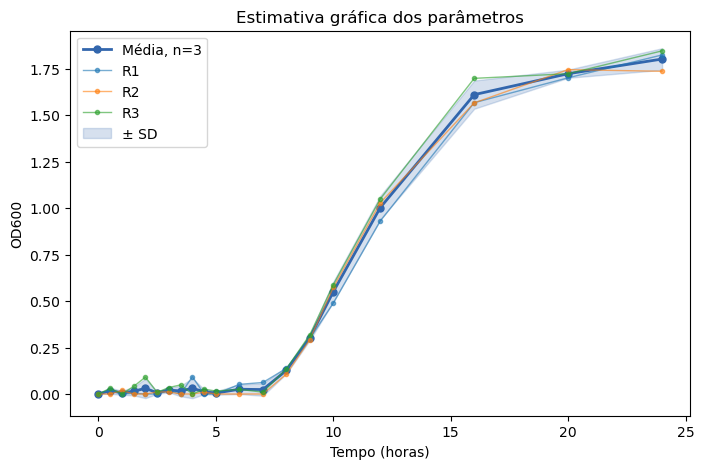

In [16]:
# --- Para o cálculo dos valores da média usa od_mean, od_std
# --- Para o cálculo dos valores das réplicas individuais usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'

fig, ax = plt.subplots(figsize=(8, 5))


# ────── Curva dos valores médios de crescimento
ax.plot(time_array, od_mean, #X = time, Y= média de OD em cada tempo
        "o-", color="#3266ad", linewidth=2, markersize=5, label='Média, n=3')

# ────── Curva dos valores de cada réplicas individual
print(df_estirpe)
for i, row in df_estirpe.iterrows():
    print(row)
    ax.plot(time_array, row[time_cols], #X = time, Y= valores de OD em CADA TEMPO
           "o-", linewidth=1, markersize=3, alpha=0.6, label=row["Replicate"]) # label usando o nome da réplica


# ────── Banda de desvio padrão
ax.fill_between(time_array, od_mean - od_std, od_mean + od_std,  # X = time, Y_baixo = valor mais baixo (média - std), Y_alto = valor mais alto (média + std)
              color="#3266ad", alpha=0.2, label="± SD")

ax.set_xlabel("Tempo (horas)")
ax.set_ylabel("OD600")
ax.set_title("Estimativa gráfica dos parâmetros")
ax.legend()

#mostra a imagem e fecha, permitindo a continua alteração da imagem
display(fig)
plt.close()

### **Questão**
- Conseguem identificar as fases lag, exponencial e estacionária?
>**Sim. A fase lag ocorre entre 0 e aproximadamente 8 horas. A fase exponencial oorre entre 8 a 16 horas, caracterizada por um aumento acentuado da OD. A fase estacionária começa a partir das 16 horas, quando os valores se tornam estáveis.**
- Como se comparam as diferentes réplicas individualmente com a média e desvio padrão?
>**R1 e R2 apresentam um comportamento mais proximo a media do que a R3, pelo R3 apresenta maior desvio padrao.**

# FASE 2 — Calcular os parâmetros de crescimento

Agora vamos passar da observação ao cálculo. Para cada estirpe, vamos estimar os 3 parâmetros de crescimento a partir dos dados:

| Passo | O que vamos fazer | Parâmetro | 
|-------|-------------------|-----------|
| 2.1 | Estimar o plateau (média dos últimos pontos) | **A** |
| 2.2 | Calcular a taxa máxima de crescimento (ΔOD/Δt) | **μ_max** |
| 2.3 | Estimar a fase lag a partir do ponto de inflexão | **λ** |

Cada grupo vai analisar **um microrganismo** e no final juntamos os resultados de todos.

### 2.1 Crescimento máximo — Plateau ou Fase Estacionária (A)

O plateau (A) representa a **densidade ótica máxima** que a cultura atinge — o ponto em que o crescimento estabiliza porque os nutrientes se esgotam ou os produtos tóxicos se acumulam.

Estimamos A como a **média dos últimos pontos temporais**, onde a curva já estabilizou.

**O que determina o valor de A?**
- **Capacidade de carga do meio:** quantidade de nutrientes disponíveis
- **Tolerância a produtos metabólicos:** ácidos, etanol, toxinas que se acumulam
- **Tamanho celular:** a mesma OD600 pode corresponder a números diferentes de células conforme o organismo (bactérias são mais pequenas que leveduras)

**Questão:** 
- Se duas estirpes crescem no mesmo meio, mas uma atinge um plateau mais alto, o que pode explicar a diferença?
>**Isso pode ser explicado por diferenças na necessidade energetica, utilizacao de nutrientes, caracteristicas particulares do proprio organismo, carateristicas do proprio meio (ausencia ou presenca de metabolitos, temperatura, ...).**

Valores selecionados: [1.61133333 1.724      1.803     ]

Estimativas gráficas para C_albicans:
  Plateau (A) média ≈ 1.712777777777778
  R1: Plateau ≈ 1.698
  R2: Plateau ≈ 1.683
  R3: Plateau ≈ 1.757


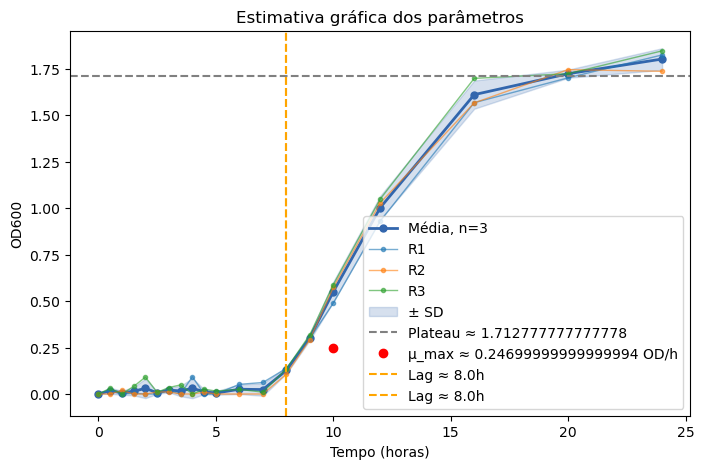

In [64]:
# --- Para o cálculo dos valores da média usa od_mean, od_std
# --- Para o cálculo dos valores das réplicas individuais usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'


# ─────────────── Plateau (A) ─────────────────────────────────────────
# ────── Calcular o plateu médio
valor_incial_A = 17 # em que valor a reta entra em A?
valores_A = od_mean[valor_incial_A:] # selecionar os valores a partir do tempo onde a curva parece estabilizar (usar o array de médias)
print(f"Valores selecionados: {valores_A}")

A_estimado = valores_A.mean() # calcular a média dos valores para obter a estimativa do plateau
print(f"\nEstimativas gráficas para {estirpe}:")
print(f"  Plateau (A) média ≈ {A_estimado}")

#visualiza o valor médio do plateau no gráfico
ax.axhline(A_estimado, color="gray", linestyle="--", label=f"Plateau ≈ {A_estimado}") 
ax.legend()

# ────── Calcular o plateau para cada réplica individualmente
for i, row in df_estirpe.iterrows():      # loop por cada réplica usando df_estirpe
    od_rep = row[time_cols].values # seleciona as colunas de valores → guarda os values de OD
    od_A_rep = od_rep[valor_incial_A:]                        # valores de A
    A_rep = od_A_rep.mean()                           # média → estimativa do plateau
    print(f"  {row['Replicate']}: Plateau ≈ {A_rep:.3f}")


display(fig)
plt.close()

### 2.2 Taxa de crescimento máxima (μ_max)

A taxa de crescimento máxima corresponde à **inclinação máxima** da curva — o momento em que as células se estão a dividir mais rapidamente (fase exponencial).

Calculamos μ_max como a derivada numérica da curva:

$$\mu_{max} = \max\left(\frac{\Delta OD}{\Delta t}\right)$$

Ou seja, para cada par de pontos consecutivos calculamos a variação de OD por hora (ΔOD/Δt) e ficamos com o **valor máximo**.

**O que influencia μ_max?**
- **Tipo de divisão celular:** bactérias (fissão binária, ~20 min) vs leveduras (gemulação, ~90 min)
- **Meio de cultura:** disponibilidade de nutrientes, temperatura, pH
- **Metabolismo:** aeróbio vs anaeróbio, fermentativo vs respiratório


[0.         0.01766667 0.00633333 0.015      0.03033333 0.00666667
 0.02133333 0.01633333 0.031      0.012      0.00533333 0.02566667
 0.024      0.12666667 0.30366667 0.55066667 1.00333333 1.61133333
 1.724      1.803     ]
Taxa de crescimento (ΔOD): [ 0.01766667 -0.01133333  0.00866667  0.01533333 -0.02366667  0.01466667
 -0.005       0.01466667 -0.019      -0.00666667  0.02033333 -0.00166667
  0.10266667  0.177       0.247       0.45266667  0.608       0.11266667
  0.079     ]
Intervalos de tempo (Δt): [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 1.  1.  1.  1.  1.  2.  4.  4.
 4. ]
Taxa de crescimento por hora (ΔOD/Δt): [ 0.03533333 -0.02266667  0.01733333  0.03066667 -0.04733333  0.02933333
 -0.01        0.02933333 -0.038      -0.01333333  0.02033333 -0.00166667
  0.10266667  0.177       0.247       0.22633333  0.152       0.02816667
  0.01975   ]
O crescimento máximo de 0.24699999999999994 OD/h ocorre no tempo de 9.0 horas
  R1: μ_max ≈ 0.22100000000000003 OD/h
  R2: μ_max ≈ 0.280999

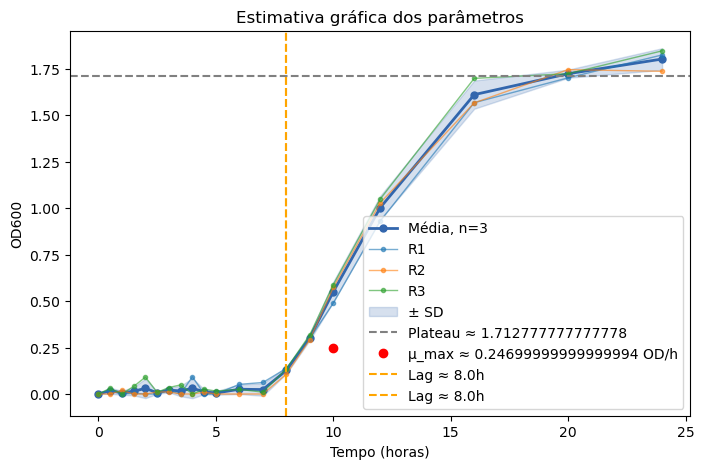

In [65]:
# --- Para o cálculo dos valores da média usa od_mean, od_std
# --- Para o cálculo dos valores das réplicas individuais usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'


# ─────────────── Taxa máxima (mu) ────────────────────────────────────

# ────── Calcular o mu médio
# -- np (numpy é usado para trabalhar com arrays e fazer operações amtemáticas)
dod = np.diff(od_mean) # calcular a diferença entre os valores de OD para obter a taxa de crescimento
print(od_mean)
print(f"Taxa de crescimento (ΔOD): {dod}")

dt = np.diff(time_array) # calcular intervalo de tempo
print(f"Intervalos de tempo (Δt): {dt}")

dod_dt = dod/dt # aplicar a fórmula da taxa de crescimento (ΔOD/Δt)
print(f"Taxa de crescimento por hora (ΔOD/Δt): {dod_dt}")

mu_estimado  = dod_dt.max() # encontrar o valor máximo de μ_max no ARRAY de valores


idx_max = np.argmax(dod_dt) # encontrar o índice no array no valor máximo
time_mu_max  = time_array[idx_max] # para identificar o tempo correspondente
print(f"O crescimento máximo de {mu_estimado} OD/h ocorre no tempo de {time_mu_max} horas")

# ────── Calcular mu para cada réplica individualmente
for i, row in df_estirpe.iterrows():
    od_rep      = row[time_cols].values # extrair os valores de OD da réplica
    dod_dt_rep  = np.diff(od_rep)/np.diff(time_array) # calcular a taxa de crescimento da réplica
    mu_rep      = dod_dt_rep.max() # estimar μ_max da réplica
    print(f"  {df_estirpe.loc[i, 'Replicate']}: μ_max ≈ {mu_rep} OD/h")


# --- plot no gráfico
ax.plot(time_array[idx_max] +1, dod_dt[idx_max], "o", color="red", 
        label=f"μ_max ≈ {mu_estimado} OD/h")
ax.legend()

print(f"Estimativas gráficas para {estirpe}:")
print(f"  Plateau (A)  ≈ {A_estimado:.3f}")
print(f"  μ_max        ≈ {mu_estimado:.3f} OD/h")

display(fig)
plt.close()

### 2.3 Estimativa da Fase Lag (λ)

A fase lag é calculada a partir do ponto de inflexão da curva:

$$\lambda = t_{inf} - \frac{OD_{inf} - OD_0}{\mu_{max}}$$

Onde:
- **lambda** — tempo da fase lag (se λ = 2 horas, significa que a cultura ficou cerca de 2 horas em adaptação antes de crescer rapidamente)
- **t_inf** — tempo no ponto de inflexão (onde o crescimento é mais rápido)
- **OD_inf** — valor de OD nesse ponto
- **OD_0** — valor de OD no tempo zero
- **μ_max** — taxa de crescimento máxima (calculada no passo anterior)

Ouuuu....

Podemos estimar quando a OD ultrapassa o valor de inicial.

#### **Questão:** 
- Um organismo com uma fase lag longa é vantajoso ou desvantajoso? Depende do contexto?
>**Um organismo com uma fase lag longa pode ser vantajoso ou desvantajoso, dependendo do contexto. Porque se for um patogeno e considerado vantajoso no sentido em que da uma janela de tempo necessario para que o sistema imunologico atue de modo a explulsar o patogeno. No caso de um microrganismo comensal, ter uma fase lag longa pode ser desvantajoso porque em muitos casos a sua ausencia no meio da espaco ao crescimento de microrganismos patogenicos**

Limite de crescimento em fase Lag: 0.1
Valores acima do threshold: [False False False False False False False False False False False False
 False  True  True  True  True  True  True  True]
Tempos acima do crescimento lag: [ 8.  9. 10. 12. 16. 20. 24.]
Tempo que o crescimento sai de fase lag: 8.0
  R1: Lag ≈ 8.0 h
  R2: Lag ≈ 8.0 h
  R3: Lag ≈ 8.0 h
Estimativas gráficas para C_albicans:
  Plateau (A)  ≈ 1.712777777777778
  μ_max        ≈ 0.24699999999999994 OD/h
  Fase lag     ≈ 8.0 h


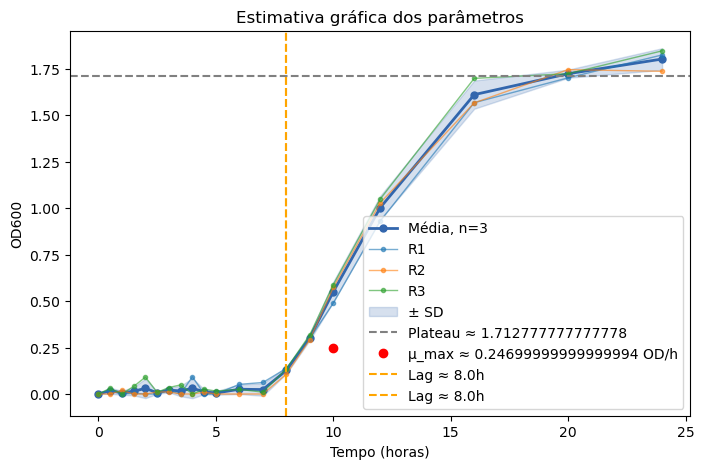

In [66]:
# --- Para o cálculo dos valores da média usa od_mean, od_std
# --- Para o cálculo dos valores das réplicas individuais usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'

# ────── Calcular lam da média
threshold = od_mean[0] + 0.1 # OD inicial + margem para ignorar ruído
print(f"Limite de crescimento em fase Lag: {threshold}")

array_valores_acima_threshold = od_mean > threshold # cria um array booleano (True/False) dos valores de od_mean acima do threshold defnido
print(f"Valores acima do threshold: {array_valores_acima_threshold}")

valores_tempo_acima_threshold = time_array[array_valores_acima_threshold] # Retira os valores de tempo onde True
print(f"Tempos acima do crescimento lag: {valores_tempo_acima_threshold}")

lam_estimado = valores_tempo_acima_threshold[0] # primeiro tempo onde OD ultrapassa o threshold
print(f"Tempo que o crescimento sai de fase lag: {lam_estimado}")

# ────── Calcular lam para cada réplica individualmente
for i, row in df_estirpe.iterrows():
     threshold_rep = od_rep[0] + 0.1
     array_valores_acima_threshold_rep = od_rep > threshold_rep
     valores_tempo_acima_threshold_rep = time_array[array_valores_acima_threshold_rep]
     lam_rep = valores_tempo_acima_threshold_rep[0]
     print(f"  {df_estirpe.loc[i, 'Replicate']}: Lag ≈ {lam_rep} h")

ax.axvline(lam_estimado, color="orange", linestyle="--", label=f"Lag ≈ {lam_estimado}h") # representar graficamente
ax.legend()

print(f"Estimativas gráficas para {estirpe}:")
print(f"  Plateau (A)  ≈ {A_estimado}")
print(f"  μ_max        ≈ {mu_estimado} OD/h")
print(f"  Fase lag     ≈ {lam_estimado} h")

display(fig)
plt.close()

# FASE 3 — Comparar o crescimento das diferentes estirpes

### 3.1 Tabela resumo dos parâmetros de crescimento

Depois de estimados os parâmetros para todas as estirpes, compilamos os resultados numa tabela com a **média ± desvio-padrão** (3 réplicas) de cada parâmetro:

| Parâmetro | O que representa | Como foi estimado |
|---|---|---|
| **A** (mean ± sd) | Plateau — densidade máxima atingida | Média dos últimos 5 pontos temporais |
| **μ_max** (mean ± sd) | Taxa de crescimento máxima | Máximo de ΔOD/Δt na fase exponencial |
| **λ** (mean ± sd) | Fase lag — tempo até iniciar crescimento | Fórmula: λ = t_inf − (OD_inf − OD₀) / μ_max |

A tabela resultante terá este formato — **uma linha por estirpe, com média e desvio-padrão de cada parâmetro**:

| Strain | Replicate | A_mean | A_sd | mu_mean | mu_sd | lam_mean | lam_sd |
|---|---|---|---|---|---|---|---|
| C_albicans | ... | ... | ... | ... | ... | ... | ... |
| C_difficile | ... | ... | ... | ... | ... | ... | ... |
| E_coli_K12 | ... | ... | ... | ... | ... | ... | ... |
| L_acidophilus | ... | ... | ... | ... | ... | ... | ... |
| S_cerevisiae | ... | ... | ... | ... | ... | ... | ... |
| Salmonella_enterica | ... | ... | ... | ... | ... | ... | ... |



In [94]:
# --- Para o cálculo de todos os dados usa a dataframe 'df_estirpe' e colunas de dados 'time_cols'

#────── Criar dataframe vazia para guardar os resultados
df_resultados = pd.DataFrame(columns = ["Strain", "Replicate", "A", "mu", "lam"])

#────── Criar função para calcular os diferentes parâmetros de crescimento
def calcular_parametros(t, od): # cria função para calcular os parÂmetros de crescimento
    
    # Plateau — média dos últimos 20% dos pontos
    n_plateau = int(0.2 * len(od))
    A = od[-n_plateau:].mean()

    # mu máximo
    dod_dt = np.diff(od)/np.diff(t)
    idx_max = np.argmax(dod_dt)
    mu      = np.max(dod_dt)
    
    # Fase lag — threshold
    threshold = od[0] +0.1
    lam = t[od > threshold][0]
    
    return A, mu, lam

#────── Calcular e armazenar os parâmetros de crescimento para todas as estirpes
for estirpe in df["Strain"].unique(): # iterar por estirpe
    df_estirpe = df[df["Strain"] == estirpe] # filtrar por estirpe
    df_estirpe_time = df_estirpe[time_cols] # manter apenas colunas com valores de crescimento
    
    for i, row in df_estirpe.iterrows(): # iterar por réplica
        od_rep = row[time_cols].values # valores de OD da linha 
        A, mu, lam = calcular_parametros(time_array, od_rep)
        
        #guardar resultados
        df_resultados.loc[i, "Strain"]    = estirpe
        df_resultados.loc[i, "Replicate"] = df_estirpe.loc[i, "Replicate"]
        df_resultados.loc[i, "A"] = A
        df_resultados.loc[i, "mu"] = mu
        df_resultados.loc[i, "lam"] = lam


print("Parâmetros por réplica:")
print(df_resultados)

#────── Colapsar em valores médios, calculando o desvio padrão
df_resumo = df_resultados.groupby("Strain").agg(  #agrupar as diferentes linhas pela coluna strain, agregando...
    A_mean=("A", "mean"), A_sd=("A", "std"), # coluna A_mean em que agregamos os valores de A pela média e coluna A_std em que agregamos os valores de A pelo desvio padrão
    mu_mean = ("mu", "mean"), mu_sd=("mu", "std"), # repete para mu
    lam_mean = ("lam", "mean"), lam_sd=("lam", "std") # repete para lam
).round(3)
print("\nResumo (média ± SD por estirpe):")
print(df_resumo)

Parâmetros por réplica:
                 Strain Replicate        A     mu  lam
0            E_coli_K12        R1  2.87975  1.972  2.0
1            E_coli_K12        R2   2.7845  1.944  2.0
2            E_coli_K12        R3   2.7195  1.782  2.5
3   Salmonella_enterica        R1  2.55375   1.62  2.5
4   Salmonella_enterica        R2  2.54975  1.606  2.5
5   Salmonella_enterica        R3  2.77125  1.528  3.0
6         L_acidophilus        R1  1.89175   0.63  6.0
7         L_acidophilus        R2  2.16425  0.666  4.5
8         L_acidophilus        R3  1.93875  0.618  6.0
9           C_difficile        R1  2.39325  0.501  1.0
10          C_difficile        R2  2.00575  0.584  5.0
11          C_difficile        R3  2.15375  0.475  6.0
12         S_cerevisiae        R1  2.21225  0.486  7.0
13         S_cerevisiae        R2    2.167  0.378  6.0
14         S_cerevisiae        R3    2.259  0.399  7.0
15           C_albicans        R1   1.5065  0.221  8.0
16           C_albicans        R2  1.5197

#### **Questão:** 
- Qual a estirpe com maior variabilidade (SD alto) em cada parâmetro? O que pode explicar isso?
>**No parametro A_sd e no lam_sd o** *C_difficile* **e que tem maior variabilidade. No parametro mu_sd a** *E_coli_K12* **apresenta maior variabilidade.** **No caso de** *C_difficile* **a dispersao dos dados poderia ser explicada por diferencas ambientais ou fisicas, diferencas na quantidade de inoculo, alguns erros tecnicos como consentracao do meio de cultura, erros na leitura espectofotometrica e variabilidade natural da especie.**

### 3.1 Simulação das curvas de crescimento — Modelo de Gompertz

Tendo os 3 parâmetros estimados (A, μ_max, λ) para cada estirpe, podemos reconstruir a curva de crescimento completa usando o **modelo de Gompertz modificado**:

$$OD(t) = A \cdot \exp\left(-\exp\left(\frac{\mu_{max} \cdot e}{A} \cdot (\lambda - t) + 1\right)\right)$$

Isto permite-nos **sobrepor todas as estirpes no mesmo gráfico** e comparar visualmente.

| Parâmetro | Símbolo | Unidade | Significado biológico |
|---|---|---|---|
| Medida de Crescimento | OD(t) | h | OD da população de microrganismos no tempo \(t\)|
| Tempo | t | h | Variável independente — o tempo decorrido desde o início do ensaio. |
| Número de Euler | e | — | Constante matemática (≈ 2,718).|

Fórmula:
- A estrutura é uma **exponencial dupla** (exp dentro de exp), o que gera a forma sigmoide assimétrica característica.
- O termo **e** na fórmula é o número de Euler (≈ 2,718), e aparece como fator de escala que garante que μ_max corresponda exatamente à taxa máxima de crescimento — é uma consequência da derivação matemática do modelo, não um parâmetro ajustável.
- O argumento interno, **(μ_max · e / A) · (λ − t) + 1**, controla a transição entre as fases.
- Quando **t ≪ λ**, (λ − t) é grande e positivo, a exponencial interna é muito grande, e a exponencial externa tende a zero — a população ainda não cresceu.
- Quando **t ≫ λ**, (λ − t) torna-se muito negativo, a exponencial interna tende a zero, e OD(t) tende a A — a população atingiu o máximo.
- A transição entre estes extremos dá-nos a **fase exponencial**.

                       A_mean   A_sd   mu_mean  mu_sd  lam_mean  lam_sd
Strain                                                                 
C_albicans           1.535417  0.039  0.257333  0.032       8.0   0.000
C_difficile           2.18425  0.196      0.52  0.057       4.0   2.646
E_coli_K12           2.794583  0.081  1.899333  0.103  2.166667   0.289
L_acidophilus         1.99825  0.146     0.638  0.025       5.5   0.866
S_cerevisiae          2.21275  0.046     0.421  0.057  6.666667   0.577
Salmonella_enterica  2.624917  0.127  1.584667  0.050  2.666667   0.289
Linha temporal criada: [ 0.          0.12060302  0.24120603  0.36180905  0.48241206  0.60301508
  0.72361809  0.84422111  0.96482412  1.08542714  1.20603015  1.32663317
  1.44723618  1.5678392   1.68844221  1.80904523  1.92964824  2.05025126
  2.17085427  2.29145729  2.4120603   2.53266332  2.65326633  2.77386935
  2.89447236  3.01507538  3.13567839  3.25628141  3.37688442  3.49748744
  3.61809045  3.73869347  3.85929648

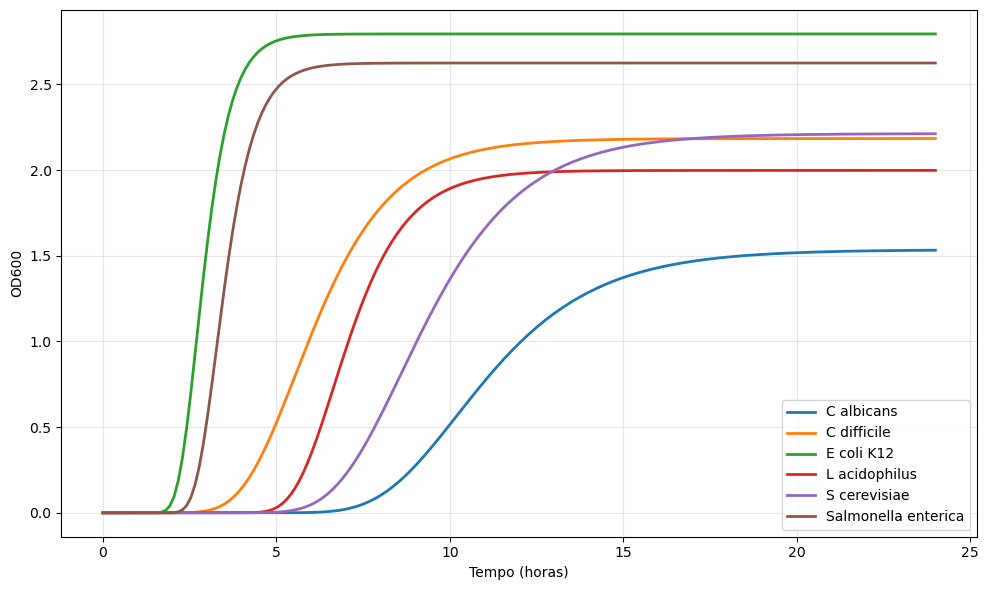

In [88]:
# Para a simulação usa a dataframe df_resumo
print(df_resumo)

# ────── Cria o gráfico
fig_all, ax_all = plt.subplots(figsize=(10, 6))

# ────── Função que faz a simulação da curva por estirpe
def gompertz(t, A, mu, lam):
    return A * np.exp(-np.exp((mu * np.e / A) * (lam - t) + 1))
    
# ---np.linspace(start, stop, num) — cria um array de num valores igualmente espaçados entre start e stop.
t_curva = np.linspace(0, time_array[-1], 200)
print(f"Linha temporal criada: {t_curva}")

# ────── simula a curva por cada estirpe
for estirpe in df_resumo.index.unique():       #onde estão as estirpes detalhadas?: estirpes estão no index
    params = df_resumo.loc[estirpe]    #retira os valores da estirpe da df_resumo
    print(params)                      #retira os valores da estirpe da df_resumo
    od_curva = gompertz(t_curva, params["A_mean"], params["mu_mean"], params["lam_mean"]) #insere os valores necessários para a função
    ax_all.plot(t_curva, od_curva, linewidth=2, label=estirpe.replace("_", " ")) #plota a linha no gráfico - X = tempo, Y = ods calculados por gompertz

ax_all.set_xlabel("Tempo (horas)")
ax_all.set_ylabel("OD600")
ax_all.legend()
ax_all.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **Questão:** 

- Quem arranca primeiro? (λ mais curto = curva desloca-se para a esquerda)
>**A estirpe que arranca primeiro é E. coli K12, pois apresenta uma fase lag mais curta**
- Quem cresce mais rápido? (μ_max maior = curva mais íngreme)
>**A estirpe que cresce mais rapidamente é E. coli K12, pois apresenta o maior valor de μ_max.**
- Quem atinge maior densidade? (A maior = plateau mais alto)
>**A estirpe que atinge maior densidade é E. coli K12, pois apresenta o maior valor de A.**
- Olhando para o gráfico, consigam identificar os dois grandes grupos (bactérias vs leveduras). O que os distingue?
>**As bactérias se destiguem das leveduras por estas apresentarem tempo de adaptacao mais curto, um crescimento exponencial mais acentuado e possuirem um plateau mais alto enquanto que as leveduras tem maior tempo de adaptacao, crescimento exponencial menor e um plateau mais baixo.**

### 3.2 Visualização comparativa de parâmetros de crescimento

Para facilitar a comparação dos parâmetros de crescimento, é possivel criar visualização de gráfico de barras de todas as estirpes.

                       A_mean   A_sd   mu_mean  mu_sd  lam_mean  lam_sd
Strain                                                                 
C_albicans           1.535417  0.039  0.257333  0.032       8.0   0.000
C_difficile           2.18425  0.196      0.52  0.057       4.0   2.646
E_coli_K12           2.794583  0.081  1.899333  0.103  2.166667   0.289
L_acidophilus         1.99825  0.146     0.638  0.025       5.5   0.866
S_cerevisiae          2.21275  0.046     0.421  0.057  6.666667   0.577
Salmonella_enterica  2.624917  0.127  1.584667  0.050  2.666667   0.289
lista de estirpes: Index(['C_albicans', 'C_difficile', 'E_coli_K12', 'L_acidophilus',
       'S_cerevisiae', 'Salmonella_enterica'],
      dtype='object', name='Strain')


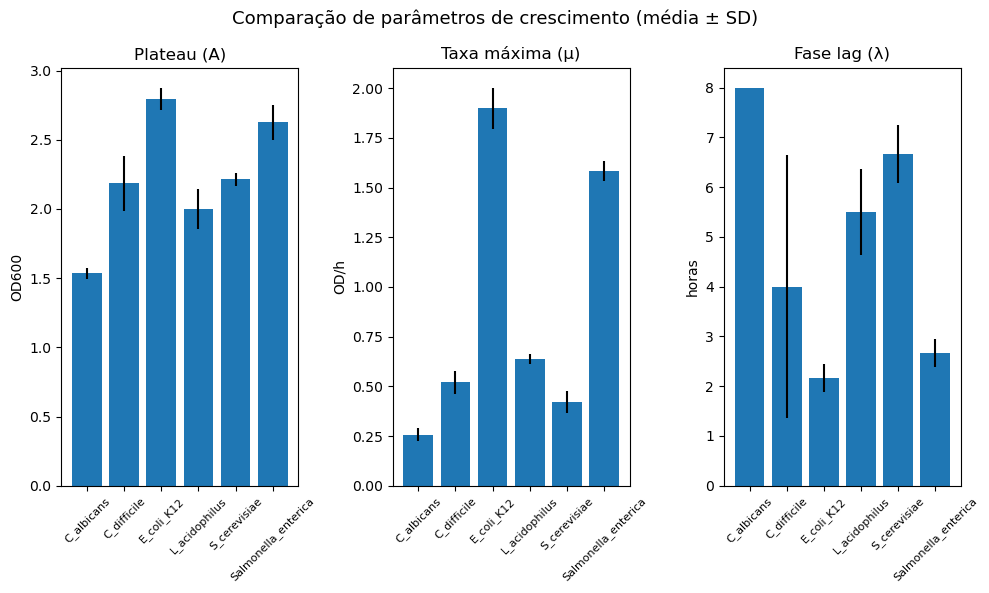

In [84]:
# Para a visualização usa a dataframe 'df_resumo'
print(df_resumo)

# ────── Cria figura com espaço para 3 gráficos
fig_all, ax_bar = plt.subplots(1, 3, figsize=(10, 6))

# --- No params_plot definimos o que queremos ver em cada gráfico
# --- mean_col, sd_col, titulo, unidade
params_plot = [
    ("A_mean",   "A_sd",   "Plateau (A)",     "OD600"),
    ("mu_mean",  "mu_sd",  "Taxa máxima (µ)", "OD/h"),
    ("lam_mean", "lam_sd", "Fase lag (λ)",    "horas"),
]

estirpes = df_resumo.index # retira as estirpes da df_resumo - index
print(f"lista de estirpes: {estirpes}")

# ────── Criar um gráfico de barras para cada parâmetro e cada estirpe
# --- O zip vai retirar os todos os valores em ax_bar e params_plot
for ax, (mean_col, sd_col, titulo, unidade) in zip(ax_bar, params_plot):    
    valores = df_resumo[mean_col].values   #Retira da df_resumo os values da média - media_col
    erros   = df_resumo[sd_col].values     #Retira da df_resumo os values da média - sd_co

    bars = ax.bar(estirpes, valores, yerr=erros) # X = estirpes, Y = valores de média, yerr = valores para as barras de erro

    ax.set_xticks(range(len(estirpes)))
    ax.set_xticklabels(estirpes, fontsize=8, rotation=45)
    ax.set_title(titulo)
    ax.set_ylabel(unidade)

plt.suptitle("Comparação de parâmetros de crescimento (média ± SD)", fontsize=13)
plt.tight_layout()
plt.show()

#### **Questão:** 
- Comparem A com μ_max: os organismos que crescem mais rápido são os que atingem maior densidade?
>De forma geral, sim. Contudo, observa-se tambem uma tendência de organismos com taxa crescimento (μ_max) menor ou moderado também atingerem densidades (A) relativamente altas.

### 3.3 Os parâmetros de crescimento são estatisticamente diferentes entre estirpes?

Visualmente, as curvas e gráficos de barras parecem diferentes — mas será que essas diferenças são **estatisticamente significativas** ou podem ser apenas variabilidade experimental?

Para responder, vamos aplicar:

1. **ANOVA One-way** — testa se existe pelo menos uma estirpe diferente das outras (para cada parâmetro)
2. **Tukey HSD (Honestly Significant Difference)** (post-hoc) — se a ANOVA for significativa, identifica **quais pares** de estirpes são diferentes

Relembrando:
- **p < 0.05** → diferença significativa (rejeitamos H₀)
- **p ≥ 0.05** → sem evidência de diferença (não rejeitamos H₀)


In [85]:
# Valores a usar estão na dataframe 'df_resultados' e a lista de estirpes na variável 'estirpes'

print(df_resultados)
print(estirpes)

for param, titulo in [("A", "Plateau (A)"), ("mu", "Taxa máxima (µ)"), ("lam", "Fase lag (λ)")]:

    # ── Preparar Valores ────────────────────
    # criar um dicionário com os valores do parâmetro por estirpe
    grupos = {}

    for e in estirpes:
        df_estirpe_params = df_resultados[df_resultados["Strain"] == e]  # filtrar para a estirpe
        grupos[e] = df_estirpe_params[param].values.astype(float)        # array para o parÂmetro (já tens a variável no primeiro for loop, com os 3 values das réplicas e converte em float (.astype)
    print(f"Grupos: {grupos}")

    if len(grupos) < 2:
        print("Erro: menos de 2 grupos")
        continue

    # ── ANOVA entre todas as estirpes ────────────────────
    f_stat, p_anova = stats.f_oneway(*grupos.values()) # * grupos = a stats.f_oneway(grupos["E_coli_K12"], grupos["Salmonella_enterica"], grupos["L_acidophilus"], ...)
    # --- *grupos.values(): [1.5065  1.51975 1.58   ] [2.39325 2.00575 2.15375] [2.87975 2.7845  2.7195 ] [1.89175 2.16425 1.93875] [2.21225 2.167   2.259  ] [2.55375 2.54975 2.77125]
    print(f"\nANOVA (todas as estirpes): F={f_stat}, p={p_anova}")

    # ── Tukey HSD post-hoc ───────────────────────────────
    valores = np.concatenate(list(grupos.values()))
    #  --- np.concatenate(list(grupos.values())) - [1.5065  1.51975 1.58    2.39325 2.00575 2.15375 2.87975 2.7845  ....
    labels = np.repeat(list(grupos.keys()), 3) # diz que cada 3 valores são a réplica de uma espécie
    tukey = pairwise_tukeyhsd(valores, labels, alpha=0.05)
    print("\nTukey HSD:")
    print(tukey.summary())

                 Strain Replicate        A     mu  lam
0            E_coli_K12        R1  2.87975  1.972  2.0
1            E_coli_K12        R2   2.7845  1.944  2.0
2            E_coli_K12        R3   2.7195  1.782  2.5
3   Salmonella_enterica        R1  2.55375   1.62  2.5
4   Salmonella_enterica        R2  2.54975  1.606  2.5
5   Salmonella_enterica        R3  2.77125  1.528  3.0
6         L_acidophilus        R1  1.89175   0.63  6.0
7         L_acidophilus        R2  2.16425  0.666  4.5
8         L_acidophilus        R3  1.93875  0.618  6.0
9           C_difficile        R1  2.39325  0.501  1.0
10          C_difficile        R2  2.00575  0.584  5.0
11          C_difficile        R3  2.15375  0.475  6.0
12         S_cerevisiae        R1  2.21225  0.486  7.0
13         S_cerevisiae        R2    2.167  0.378  6.0
14         S_cerevisiae        R3    2.259  0.399  7.0
15           C_albicans        R1   1.5065  0.221  8.0
16           C_albicans        R2  1.51975  0.281  8.0
17        

#### **Questões**

- Para qual dos 3 parâmetros (A, μ, λ) existem mais diferenças significativas entre estirpes?
>**O parâmetro com mais diferenças significativas entre estirpes é μ_max, pois apresenta os menores p-value e maior número de comparações significativas no teste de Tukey.**
- Há estirpes que não são significativamente diferentes entre si? Quais? Faz sentido biologicamente?
>**Sim, existem estirpes que não apresentam diferenças estatisticamente significativas, como por exemplo  *E. coli* e *Salmonella enterica* (para A) e *C_albicans* e *S_cerevisiae* (para λ). Isto faz sentido biologicamente, pois tem características semelhantes e pertecem a mesma classe. Os primeiros sao enterobatecterias e os segundos sao leveduras.*
- *E. coli* e *Salmonella* (ambas Enterobacteriaceae) têm parâmetros semelhantes? E *S. cerevisiae* e *C. albicans* (ambas leveduras)?
>*E. coli* e *Salmonella* **apresentam parâmetros parcialmente semelhantes, especialmente no plateau (A) e fase lag (λ), onde não há diferenças significativas. No entanto, diferem na taxa de crescimento (μ_max), sugerindo diferenças na velocidade de multiplicação, apesar de pertencerem à mesma família.**

>*S. cerevisiae* e *C. albicans* **apresentam diferenças significativas no plateau (A) e na taxa de crescimento (μ_max), mas não na fase lag (λ). Isto indica que, embora ambas sejam leveduras e tenham tempos de adaptação semelhantes, diferem na eficiência de crescimento e na biomassa final atingida.**

### 3.4 Os parâmetros de crescimento são estatisticamente diferentes entre Bactérias e Leveduras

Agora agrupamos os organismos por **tipo** (bactérias vs leveduras) e testamos se há diferenças entre os dois grupos.

**Teste t de Student** — compara as médias de **dois grupos** para determinar se a diferença entre eles é estatisticamente significativa (p < 0,05).


In [86]:
# ══════════════════════════════════════════════════════════
# ANÁLISE POR GRUPO — bactérias vs leveduras
# ══════════════════════════════════════════════════════════
bacterias = ["E_coli_K12", "Salmonella_enterica", "L_acidophilus", "C_difficile"]
leveduras = ["S_cerevisiae", "C_albicans"]

for param, titulo in [("A", "Plateau (A)"), ("mu", "Taxa máxima (µ)"), ("lam", "Fase lag (λ)")]:

    # criar um dicionário com os valores do parâmetro por estirpe
    grupos = {}
    for e in estirpes:
        df_estirpe_params = df_resultados[df_resultados["Strain"] == e]  # filtrar para a estirpe
        grupos[e] = df_estirpe_params[param].values.astype(float)  # array com os 3 valores das réplicas

    #DIFERENÇA
    # juntar todos os valores de bactérias num único array
    vals_bact = np.concatenate([grupos[e] for e in bacterias])
    print('ex: vals_bact variável: {vals_bact}')
    # juntar todos os valores de leveduras num único array
    vals_lev  = np.concatenate([grupos[e] for e in leveduras])

    # ── t-test bactérias vs leveduras ────────────────────
    # -- ttest_ind(valores de crescimento das bacterias, valores de crescimento das leveduras)
    t_stat, p_ttest = stats.ttest_ind(vals_bact, vals_lev)
    print(f"\nt-test bactérias vs leveduras para {titulo}: t={t_stat:.3f}, p={p_ttest:.4f}")
    print(f"  bactérias: média={vals_bact.mean():.3f} ± {vals_bact.std():.3f}")
    print(f"  leveduras: média={vals_lev.mean():.3f} ± {vals_lev.std():.3f}")

ex: vals_bact variável: {vals_bact}

t-test bactérias vs leveduras para Plateau (A): t=2.905, p=0.0103
  bactérias: média=2.400 ± 0.342
  leveduras: média=1.874 ± 0.340
ex: vals_bact variável: {vals_bact}

t-test bactérias vs leveduras para Taxa máxima (µ): t=3.165, p=0.0060
  bactérias: média=1.161 ± 0.596
  leveduras: média=0.339 ± 0.090
ex: vals_bact variável: {vals_bact}

t-test bactérias vs leveduras para Fase lag (λ): t=-4.789, p=0.0002
  bactérias: média=3.583 ± 1.730
  leveduras: média=7.333 ± 0.745


## **Questões**

- As bactérias atingem um plateau mais alto que as leveduras? É significativo?
>**Sim. É significativo.**
- As leveduras demoram mais a iniciar o crescimento? O que pode explicar isso biologicamente?
>**Sim. Crescem mais lentamente porque apresentam uma estrutura mais complexa e um tamanho celelar maior, um metabolismo diferente. pelo que, necessitam de mais energia para a replicacao.**
- A taxa de crescimento é diferente? As bactérias dividem-se por **fissão binária** (rápido) e leveduras por **gemulação** (mais lento)
>**É diferente.**

### 3.4 Os parâmetros de crescimento são estatisticamente diferentes entre Patogénicas vs Comensais

Será que os organismos **patogénicos** crescem de forma diferente dos **comensais**? Separamos a análise para bactérias e leveduras.

| Bactérias patogénicas | Bactérias comensais | Leveduras patogénicas | Leveduras comensais |
|---|---|---|---|
| *Salmonella*, *C. difficile* | *E. coli* K12, *L. acidophilus* | *C. albicans* | *S. cerevisiae* |


In [91]:
# ── Bactérias patogénicas vs comensais ──────────────────
bact_patogenicas = ["Salmonella_enterica", "C_difficile"]
bact_comensais   = ["E_coli_K12", "L_acidophilus"]
# ── Leveduras patogénicas vs comensais ──────────────────
lev_patogenicas  = ["C_albicans"]
lev_comensais    = ["S_cerevisiae"]

for param, titulo in [("A", "Plateau (A)"), ("mu", "Taxa máxima (µ)"), ("lam", "Fase lag (λ)")]:
    
    #separador visual
    print(f"\n{'═'*55}")
    print(f"{titulo}")
    print(f"{'═'*55}")

    # criar um dicionário com os valores do parâmetro por estirpe
    grupos = {}
    for e in estirpes: #loop pelas estirpes
        df_estirpe_params = df_resultados[df_resultados["Strain"] == e]  # filtrar para a estirpe
        grupos[e] = df_estirpe_params[param].values.astype(float)        # array com os 3 valores das réplicas

    # ── Bactérias patogénicas vs comensais ───────────────
    vals_bact_pat = np.concatenate([grupos[e] for e in bact_patogenicas])     # juntar valores das patogénicas
    vals_bact_com = np.concatenate([grupos[e] for e in bact_comensais])     # juntar valores das comensais
    t_stat, p_ttest = stats.ttest_ind(vals_bact_pat, vals_bact_com)   # t-test
    print(f"\nt-test bactérias patogénicas vs comensais para {titulo}: t={t_stat:.3f}, p={p_ttest:.3f}")
    print(f"  patogénicas: média={vals_bact_pat.mean():.3f} ± {vals_bact_pat.std():.3f}")
    print(f"  comensais:   média={vals_bact_com.mean():.3f} ± {vals_bact_com.std():.3f}")

    # ── Leveduras patogénicas vs comensais ───────────────
    vals_lev_pat = np.concatenate([grupos[e] for e in lev_patogenicas])       # juntar valores das patogénicas
    vals_lev_com = np.concatenate([grupos[e] for e in lev_comensais])      # juntar valores das comensais
    t_stat, p_ttest = stats.ttest_ind(vals_lev_pat, vals_lev_com)    # t-test
    print(f"\nt-test leveduras patogénicas vs comensais para {titulo}: t={t_stat:.3f}, p={p_ttest:.3f}")
    print(f"  patogénicas: média={vals_lev_pat.mean():.3f} ± {vals_lev_pat.std():.3f}")
    print(f"  comensais:   média={vals_lev_com.mean():.3f} ± {vals_lev_com.std():.3f}")


═══════════════════════════════════════════════════════
Plateau (A)
═══════════════════════════════════════════════════════

t-test bactérias patogénicas vs comensais para Plateau (A): t=0.038, p=0.971
  patogénicas: média=2.405 ± 0.258
  comensais:   média=2.396 ± 0.410

t-test leveduras patogénicas vs comensais para Plateau (A): t=-19.416, p=0.000
  patogénicas: média=1.535 ± 0.032
  comensais:   média=2.213 ± 0.038

═══════════════════════════════════════════════════════
Taxa máxima (µ)
═══════════════════════════════════════════════════════

t-test bactérias patogénicas vs comensais para Taxa máxima (µ): t=-0.584, p=0.572
  patogénicas: média=1.052 ± 0.534
  comensais:   média=1.269 ± 0.634

t-test leveduras patogénicas vs comensais para Taxa máxima (µ): t=-4.323, p=0.012
  patogénicas: média=0.257 ± 0.026
  comensais:   média=0.421 ± 0.047

═══════════════════════════════════════════════════════
Fase lag (λ)
═══════════════════════════════════════════════════════

t-test bactéria

#### **Questões**

- Há diferenças significativas entre patogénicos e comensais dentro das bactérias? E dentro das leveduras?
>**Bactérias: Não existem diferenças estatisticamente significativas entre bactérias patogénicas e comensais para nenhum dos parâmetros (A, μ ou λ).**

>**Leveduras: Existem diferenças estatisticamente significativas entre leveduras patogénicas e comensais para todos os parâmetros analisados (A, μ e λ).**
- Se *C. albicans* (patogénica) cresce mais devagar que *S. cerevisiae* (comensal), que importância pode ter?
>**O crescimento mais lento de C. albicans pode ser vantajoso porque o comensal pode dar menos espaco para o patogeneno crescer.

# FASE 4 — Conclusões

Respondam em grupo às seguintes questões:

1. **Ranking de crescimento:** Ordenem os 6 organismos do mais rápido ao mais lento. Coincidem com o que esperavam?

>**Baseado em μ_max:**

>*E. coli K12*

>*Salmonella enterica*

>*C. difficile*

>*L. acidophilus*

>*S. cerevisiae*

>*C. albicans*

>**Sim, coincide com o esperado, pois as bactérias crescem geralmente mais rápido que as leveduras.**

3. **Bactérias vs leveduras:** Quais as principais diferenças? São estatisticamente significativas para todos os parâmetros?
>**As bactérias crescem mais rapidamente e iniciam o crescimento mais cedo, enquanto as leveduras apresentam crescimento mais lento e maior fase de adaptação. Estas diferenças são geralmente significativas, sobretudo para μ e λ.**

4. **Patogénicos vs comensais:** A patogenicidade está associada a um padrão de crescimento diferente?
>**Sim. A patogenicidade está associada a diferenças de crescimento porque o crescimento do microrganismo pode ser influenciado positivamente pela alteracao que o estado patogenico induz.**

5. **Previsão para co-cultura:** Com base nestes resultados, o que esperam que aconteça quando os 6 organismos crescerem juntos?
   - Quem vai dominar?
     >*E. coli*, por ser mais rápida e com maior A.
   - Quem pode ser eliminado?
     >*C. albicans*, por possuir um crescimento lento e fase lag longa.
   - Que mecanismos de interação podem ocorrer? (competição, produção de bacteriocinas, alteração de pH...)
     >**Competição por nutrienetes, produção de bacteriocinas, alteração de pH e exclusão competitiva.**

---

**Na próxima aula:** Vamos usar **RT-PCR** com primers específicos para verificar a presença de cada espécie numa co-cultura real — e ver se as vossas previsões estavam corretas!
